# INTERPOLATE ERA5, COMPUTE VSD

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature


import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

_________
# ERA5 data

In [114]:
era5 = ['/Users/mdemol/DATA_WIND/era5/2023_waves_interp.nc',
        '/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1726002205.1540956-13738-7-c8d88fd1-3ec7-4113-8790-c92c59938aa6.nc',#u10 etc
        #'/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1725888040.2442634-4062-7-717f5d1f-4dbc-4297-ba65-42766024d861.nc' # lon, lat wrong coords
        #'/Users/mdemol/DATA_WIND/era5/corrected_coords_d68.nc',# corrected coords
        '/Users/mdemol/DATA_WIND/era5/corrected_coords_d68_interp.nc'#ust, vst etc
       ]
era = xr.open_mfdataset(era5)
era['f'] = 2 * 2 * np.pi / 86164.1 * np.sin(era.latitude * np.pi / 180)
era = era.sortby('latitude')

In [115]:
era 

<xarray.Dataset> Size: 2GB
Dimensions:    (longitude: 61, latitude: 33, time: 3672)
Coordinates:
  * longitude  (longitude) float32 244B 0.0 0.25 0.5 0.75 ... 14.5 14.75 15.0
  * latitude   (latitude) float32 132B 36.0 36.25 36.5 36.75 ... 43.5 43.75 44.0
  * time       (time) datetime64[ns] 29kB 2023-03-01 ... 2023-07-31T23:00:00
Data variables: (12/27)
    u10        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    v10        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    t2m        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    ewss       (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    iews       (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    inss       (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    ...         ...
    swh        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    shts       (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    ust        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    vst        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    mwp        (time, latitude, longitude) float32 30MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    f          (latitude) float32 132B 8.572e-05 8.624e-05 ... 0.0001013
Attributes:
    Conventions:  CF-1.6
    history:      2024-09-10 21:05:21 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [164]:
era.mwd.max().compute()

<xarray.DataArray 'mwd' ()> Size: 8B
array(360.00111145)

__________
# Apply AGESC model 
Regionalizing the Impacts of Wind- and Wave-Induced Currents on Surface Ocean Dynamics: A Long-Term Variability Analysis in the Mediterranean Sea, Morales-Márquez 2021, https://onlinelibrary.wiley.com/doi/abs/10.1029/2020JC017104

$$ \vec{U_a}(z) = \vec{U_e}(z) +  \vec{U_{\tau_z}}(z) +\vec{U_S}(z)+ \vec{U_{ES}}(z) $$
where :

- Classical Ekman component $ \vec{U_e}(z) = \frac{\vec{\tau}}{\rho_w A_z m}e^{mz} $, $\vec{\tau} = \rho_a C_D u_{10}\vec{u_{10}}$  turbulent stress, $\rho_a=1.2$kg/m3, $C_D= (2.7/u_{10} + 0.142 +0.0764 u_{10})/1000 $, $\rho_w$ water density, $A_z = 1.07 10^{-2}$ $m^2.s^{-1}$ vertical eddy viscosity
-  Current induced by the wave radiation stress $\vec{U_{\tau_z}}(z) = \frac{\partial_X S}{\rho_w A_z m }e^{mz}$, with $\partial_X = [\partial_x S_{xx} + \partial_y S_{yx}] + i[\partial_x S_{xy} + \partial_y S_{yy}]$, $S_{xx} = E/2 cos^2(\theta_{\omega})$, $S_{xy} = S_{yx} = E/2 sin(\theta_{\omega}) cos(\theta_{\omega})$, $S_{yy} = E/2 sin^2(\theta_{\omega})$ with $E=\rho g a^2/2$
-  Stokes component $\vec{U_S}(z) = \frac{m^2 U_{S0}}{4k^2 - m^2}e^{2kz}$, $U_{S0} = a^2 \omega k (cos(\theta_{\omega}) + i sin(\theta_{\omega})$,
-  Ekman-Stokes component = non linear interaction between wind and waves acting over the entire Ekman layer, $\vec{U_{ES}}(z) = - \frac{2 k m U_{S0}}{4k^2 -m^2}e^{mz}$
-  with $m= \sqrt{if/A_z}$


In [186]:
def ua(z, era) :
    if z>0 :
        print('WARNING : z should be negative')
    #vars
    rhow = 1.03*1e3 #kg/m3
    rhoa = 1.2#kg/m3
    g = 9.81#m/s2
    a = era.swh#m
    U10 = era.u10 + 1j*era.v10#m/s
    u10 = np.sqrt(np.conj(U10)*U10)#m/s
    Cd = (2.7/u10 + 0.142 +0.0764*u10)/1e3
    R = 6378e3 #m
    Az = 1.07e-2#m2/s
    #Az = 1e-3#m2/s
    m=(1+1j)*np.sqrt(era.f/(2*Az))#/m
    tau = rhoa * Cd *u10 *U10
    #tau = era.iews + 1j *era.inss # N/m2
    E = rhow*g*a**2/2 #m.kg/s2 = N
    thetaw = era.mwd*np.pi/180 #rad
    omega = 2*np.pi/era.mwp #rad/s
    k = omega**2/g#/m
    #K = k*np.exp(1j*era.mwd*np.pi/180)
    
    # ue classical Ekman
    ue = tau/(rhow*Az*m) * np.exp(m*z)

    # utauz
    Sxx = E/2*np.cos(thetaw)**2
    Sxy = E/2*np.cos(thetaw)*np.sin(thetaw)
    Syx = Sxy
    Syy = E/2*np.cos(thetaw)**2
    dlon_dx = 1/(np.pi*R*np.cos(era.latitude * np.pi / 180))
    dlat_dy = 1/(np.pi*R)
    partialS = Sxx.differentiate('longitude')*dlon_dx + Sxy.differentiate('latitude')*dlat_dy + 1j*(Sxy.differentiate('longitude')*dlon_dx + Syy.differentiate('latitude')*dlat_dy)
    utauz = partialS/(rhow*Az*m) * np.exp(m*z)

    # us 
    us0 = a**2*omega*k*np.exp(1j*thetaw)
    us = (m**2 * us0) /(4*k**2 -m**2) *np.exp(2*k*z)

    #ues
    ues = - 2*k*m*us0/(4*k**2 - m**2)*np.exp(m*z)

    #in era
    era['ue_e'], era['ue_n'] = ue.real, ue.imag
    era['utauz_e'], era['utauz_n'] = utauz.real, utauz.imag
    era['us_e'], era['us_n'] = us.real, us.imag
    era['ues_e'], era['ues_n'] = ues.real, ues.imag
    era['us0_e'], era['us0_n'] = us0.real, us0.imag

    #Ekman rio
    if z==0 :
        theta0 = - 22.5 * np.pi / 180 * np.sign(era.f)
        beta0 = 0.6
        
        era['urio_e'] = beta0 * (np.cos(theta0) * era.iews - np.sin(theta0) * era.inss)
        era['urio_n'] = beta0 * (np.sin(theta0) * era.iews + np.cos(theta0) * era.inss)



ua(-15, era)
    

(array([1.806000e+03, 2.747000e+03, 4.402000e+03, 7.285000e+03,
        1.229900e+04, 2.146800e+04, 4.143100e+04, 8.843800e+04,
        2.576140e+05, 2.654629e+06, 3.061837e+06, 5.295220e+05,
        2.418240e+05, 1.368510e+05, 8.640400e+04, 5.860600e+04,
        4.190200e+04, 3.112400e+04, 2.289100e+04]),
 array([-1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
        -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
        -2.00000000e-01, -1.00000000e-01, -2.22044605e-16,  1.00000000e-01,
         2.00000000e-01,  3.00000000e-01,  4.00000000e-01,  5.00000000e-01,
         6.00000000e-01,  7.00000000e-01,  8.00000000e-01,  9.00000000e-01]),
 <BarContainer object of 19 artists>)

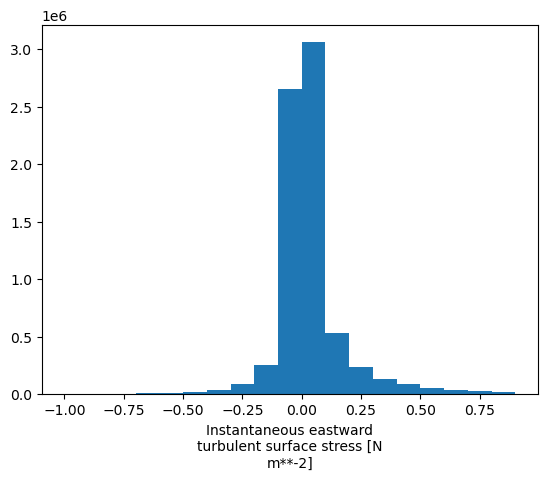

In [180]:
era.iews.plot.hist(bins = np.arange(-1, 1, 0.1))

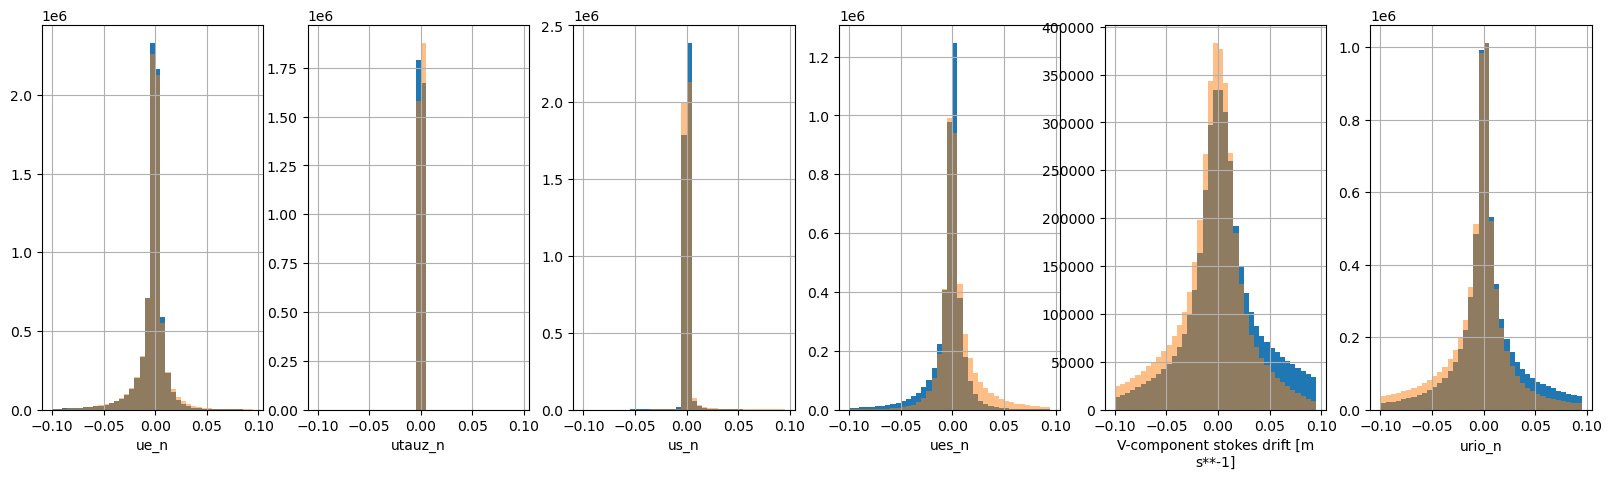

In [187]:
fig, axs = plt.subplots(1, 6 , figsize=(20, 5))
axs =axs.flatten()


bins = np.arange(-0.1, 0.1, 0.005)
ax=axs[0]
era.ue_e.plot.hist(bins = bins, ax=ax)
era.ue_n.plot.hist(bins = bins, ax=ax, alpha = 0.5)

ax=axs[1]
era.utauz_e.plot.hist(bins = bins, ax=ax)
era.utauz_n.plot.hist(bins = bins, ax=ax, alpha = 0.5)

ax=axs[2]
era.us_e.plot.hist(bins = bins,ax=ax)
era.us_n.plot.hist(bins = bins,ax=ax, alpha = 0.5)

ax=axs[3]
era.ues_e.plot.hist(bins = bins, ax=ax)
era.ues_n.plot.hist(bins = bins, ax=ax, alpha = 0.5)

ax=axs[4]
era.ust.plot.hist(bins = bins, ax=ax)
era.vst.plot.hist(bins = bins, ax=ax, alpha = 0.5)

ax=axs[5]
era.urio_e.plot.hist(bins = bins, ax=ax)
era.urio_n.plot.hist(bins = bins, ax=ax, alpha = 0.5)

for ax in axs :
    ax.grid()

In [160]:
era

<xarray.Dataset> Size: 2GB
Dimensions:    (longitude: 61, latitude: 33, time: 3672)
Coordinates:
  * longitude  (longitude) float32 244B 0.0 0.25 0.5 0.75 ... 14.5 14.75 15.0
  * latitude   (latitude) float32 132B 36.0 36.25 36.5 36.75 ... 43.5 43.75 44.0
  * time       (time) datetime64[ns] 29kB 2023-03-01 ... 2023-07-31T23:00:00
Data variables: (12/39)
    u10        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    v10        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    t2m        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    ewss       (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    iews       (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    inss       (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    ...         ...
    ues_e      (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    ues_n      (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    us0_e      (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    us0_n      (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    urio_e     (latitude, time, longitude) float64 59MB dask.array<chunksize=(33, 3672, 61), meta=np.ndarray>
    urio_n     (latitude, time, longitude) float64 59MB dask.array<chunksize=(33, 3672, 61), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2024-09-10 21:05:21 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

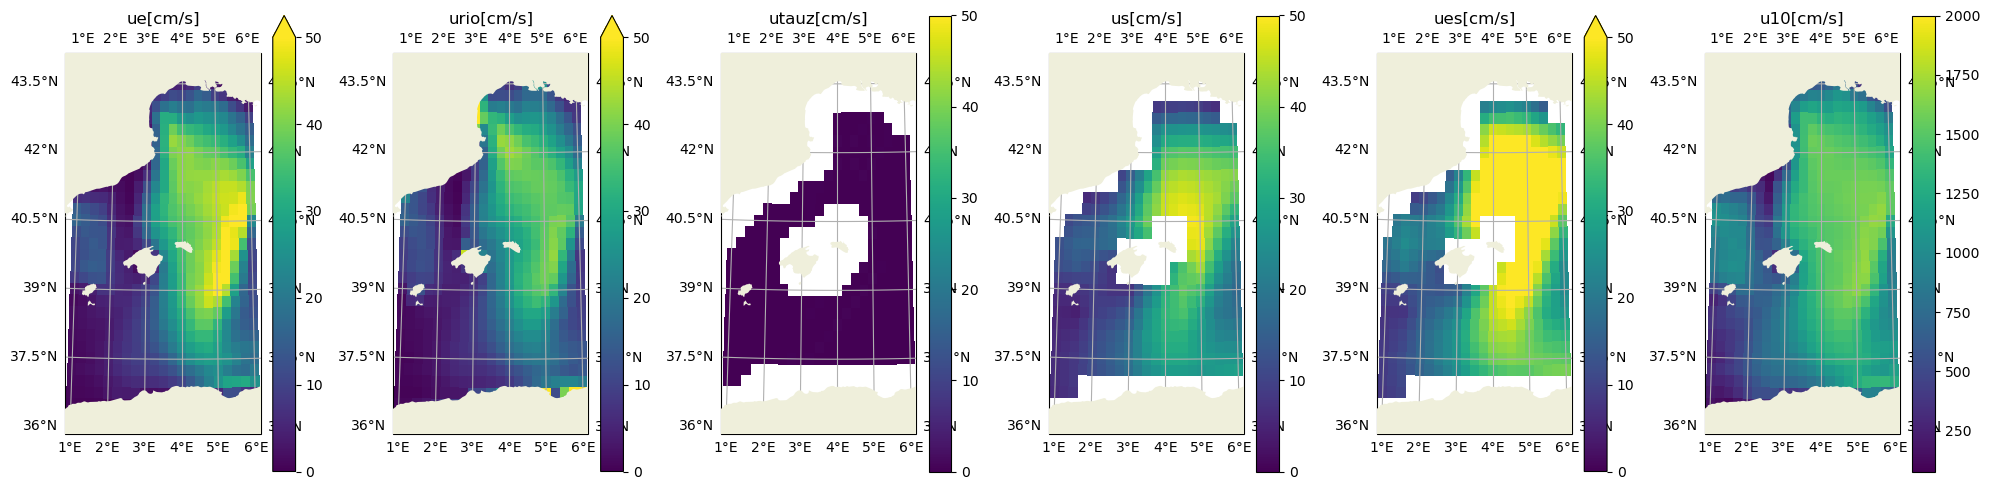

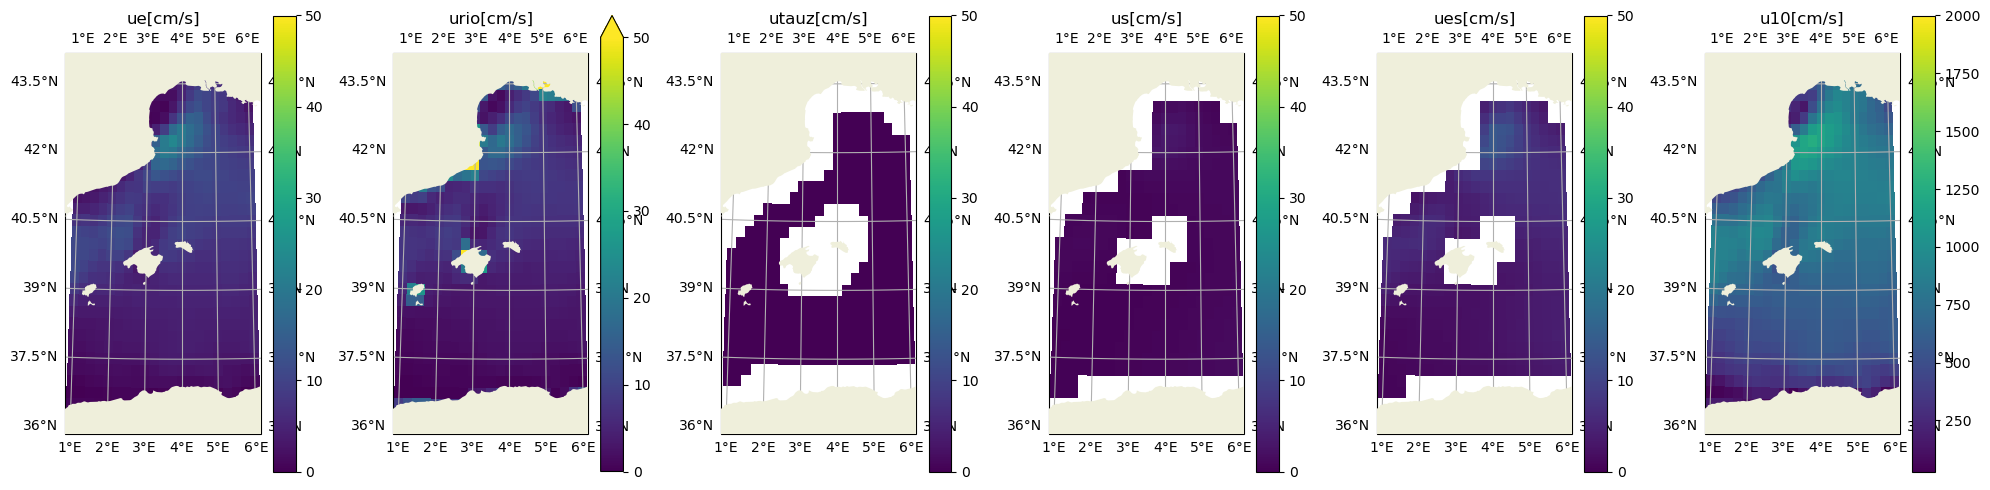

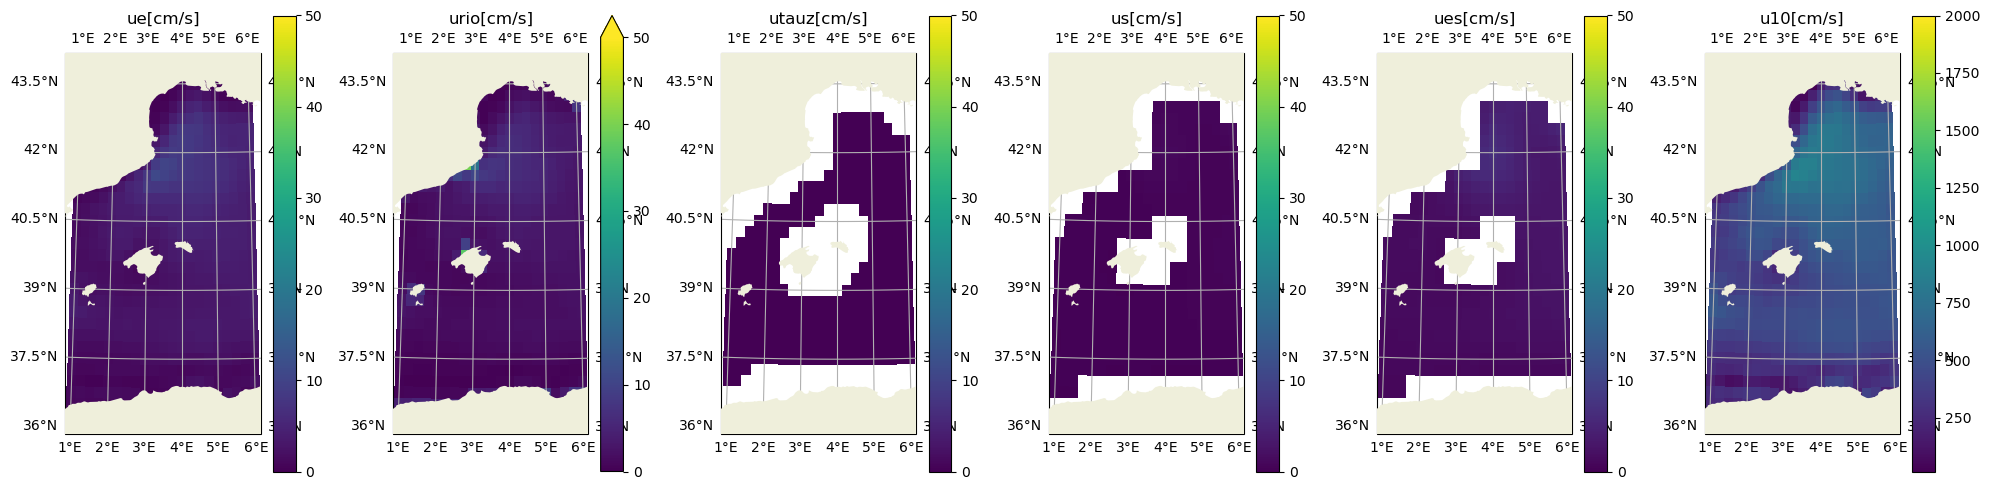

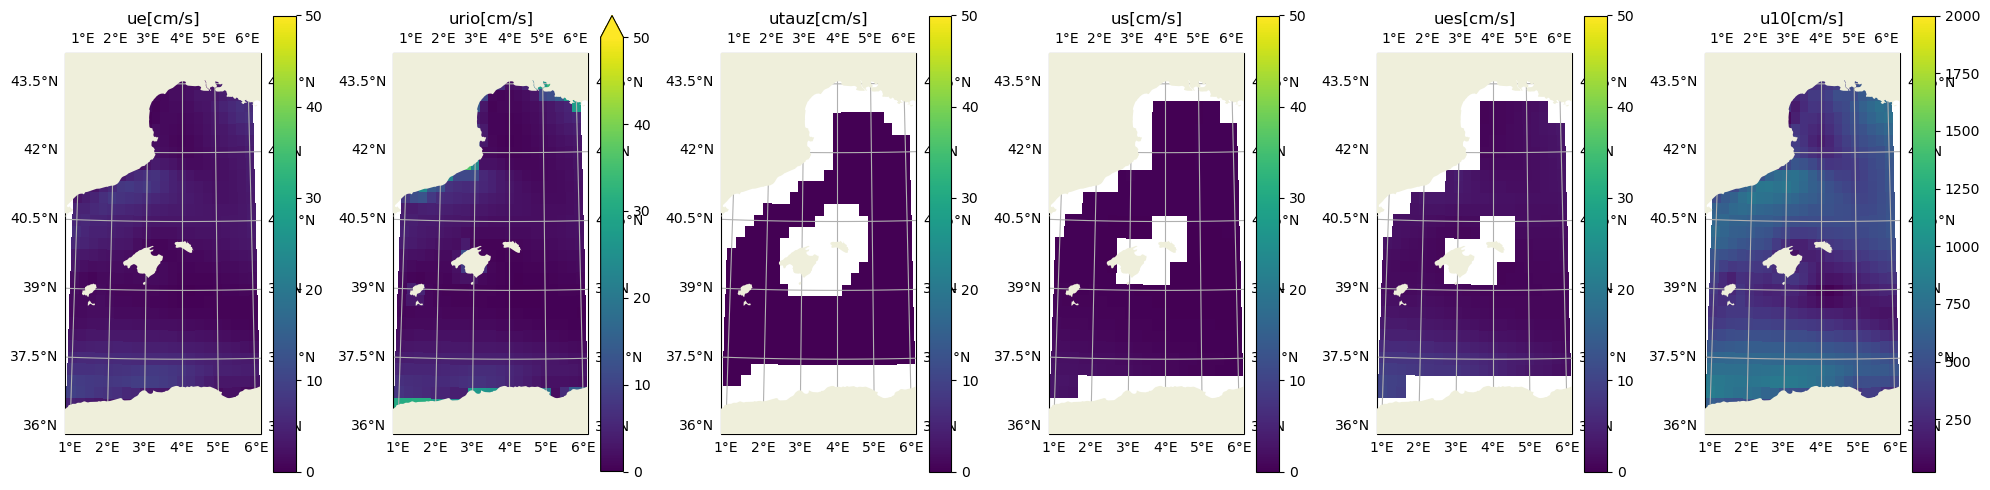

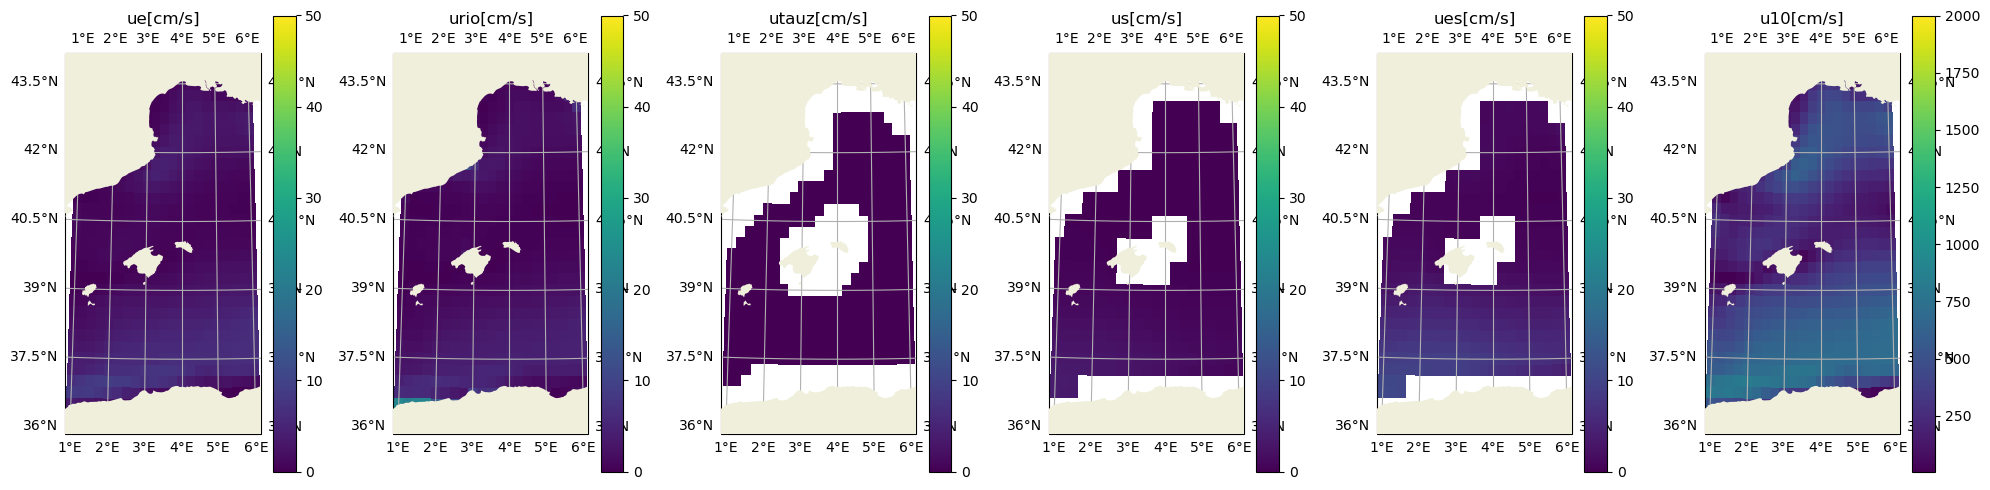

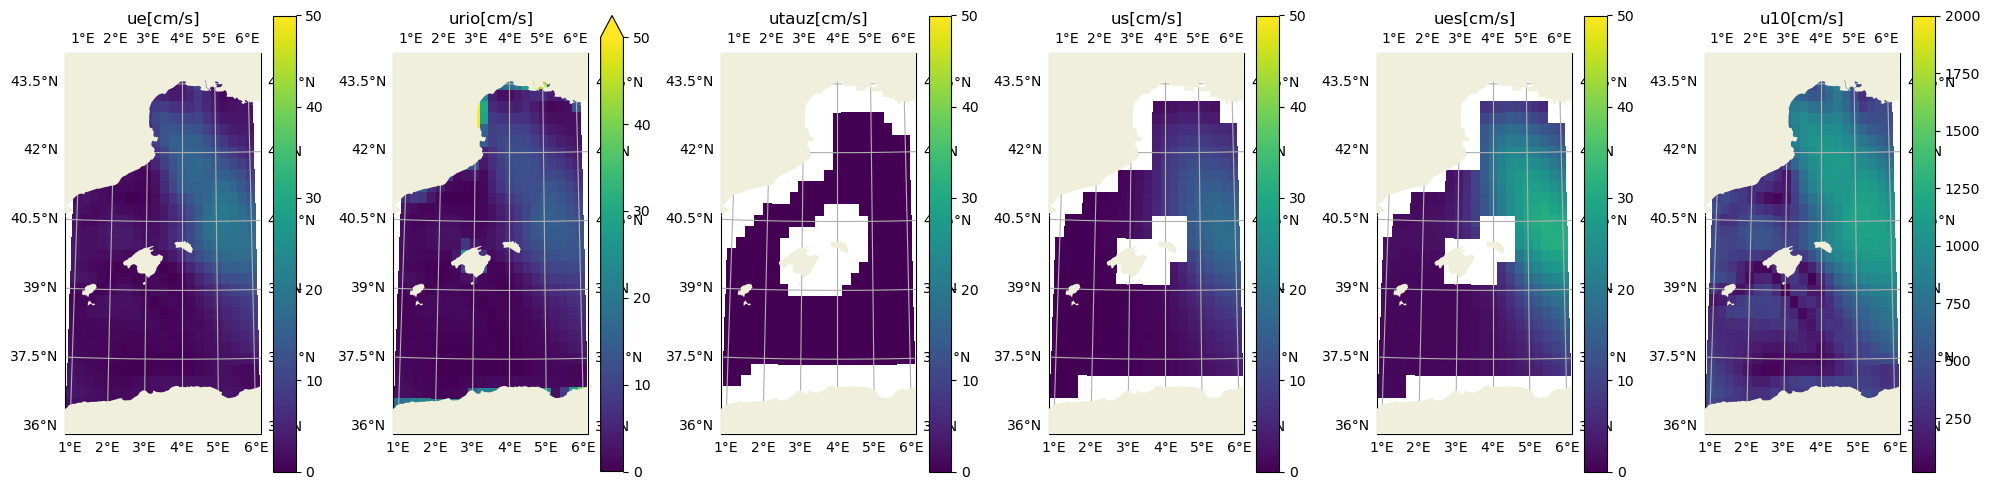

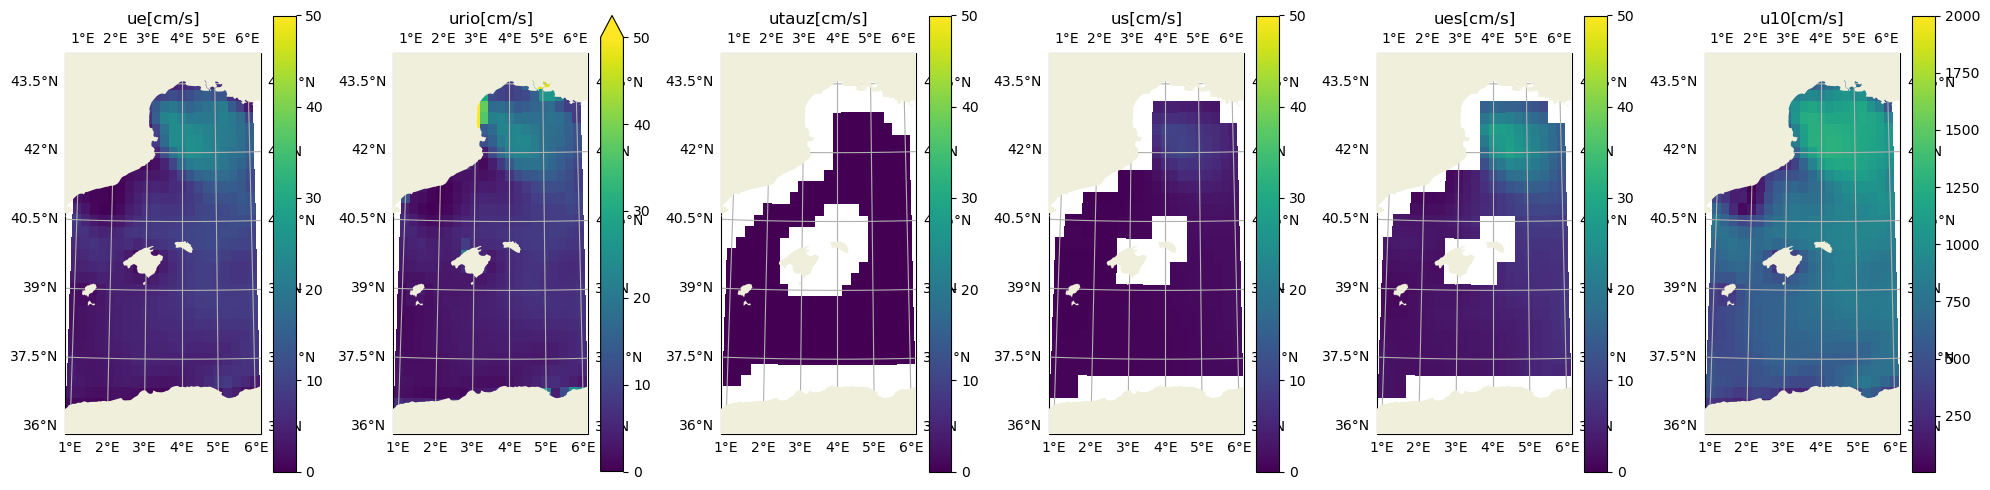

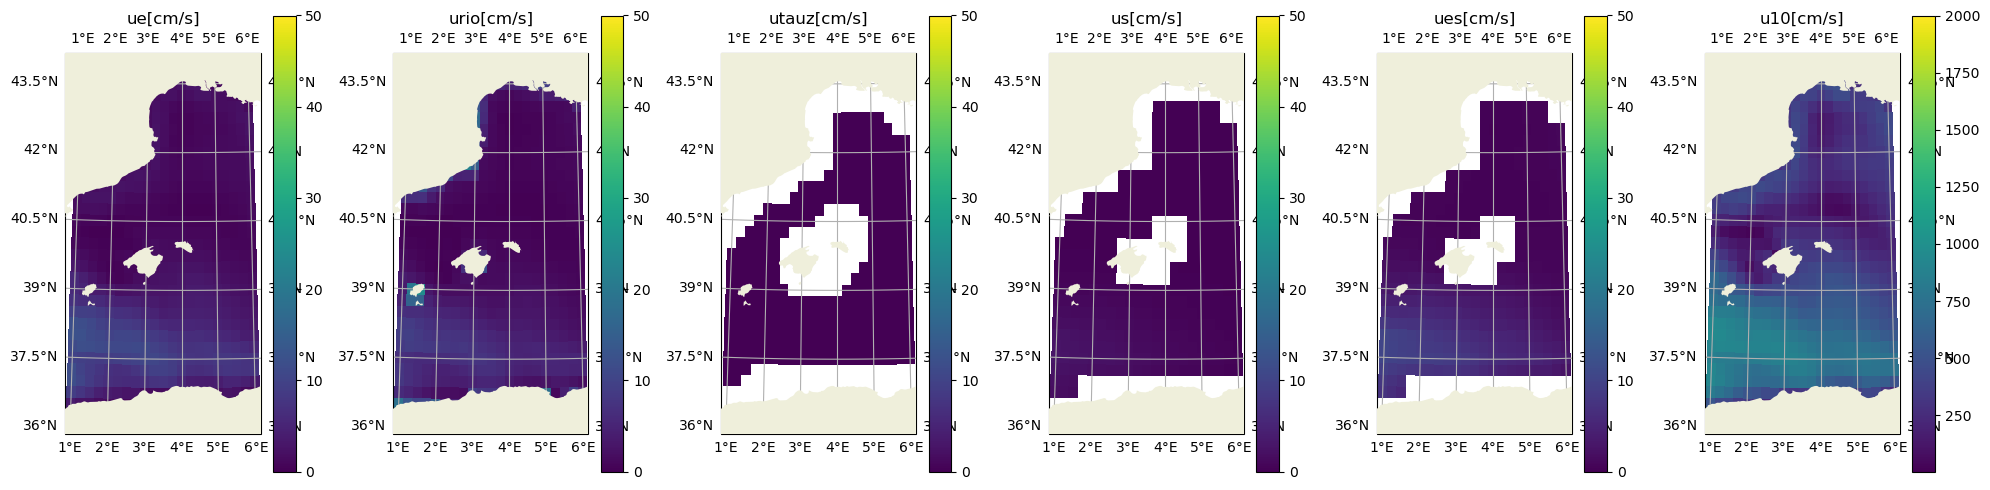

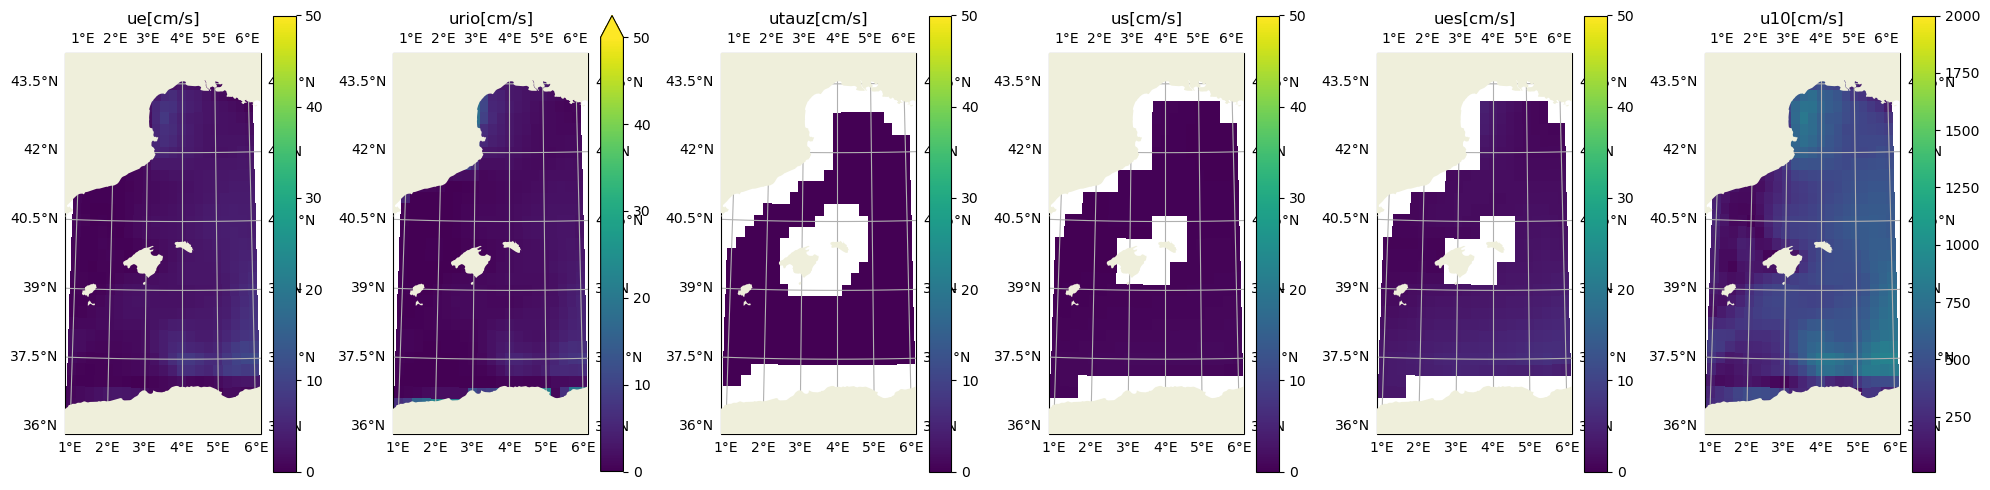

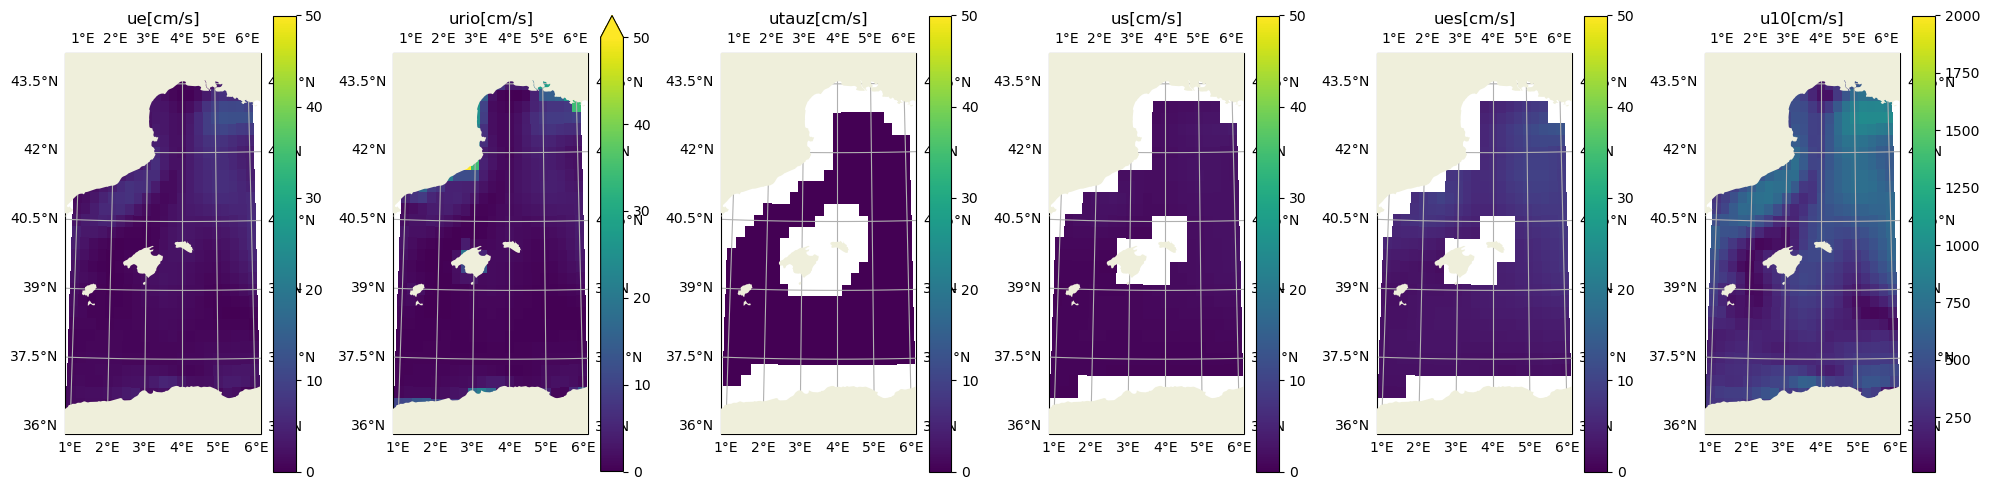

In [185]:
vmin = 0
vmax = 50
i=100
for i in range(0, 3000, 300):
    era_ = era.isel(time=i).sel(longitude = slice(1, 6))#, latitude = slice(37.5, 43.5))
    
    fig = plt.figure(figsize=(20,5))
    
    def plot_u(ekey, nkey, ax, **kwargs) : 
        (np.sqrt(era_[ekey]**2 + era_[nkey]**2)*100).plot(ax=ax, transform=crs,**kwargs)
        ax.set_title(ekey.replace('_e', '')+'[cm/s]')
        #P = era_.plot.quiver('longitude', 'latitude',ekey,nkey, color='r', scale = 100, transform=crs, ax=ax, clip_on = False, add_guide = False)
        #ax.quiverkey(P, 0.8, 0.89, 1, r'1 $m.s^{-1}$', coordinates='figure', labelpos='N')
    
        ax.add_feature(cfeature.LAND,zorder=10)
        gl = ax.gridlines(draw_labels=True,)
        
    ax = fig.add_subplot(161, projection=ccrs.Orthographic(4, 40.5))
    plot_u('ue_e', 'ue_n', ax, vmin=vmin, vmax=vmax)

    ax = fig.add_subplot(162, projection=ccrs.Orthographic(4, 40.5))
    plot_u('urio_e', 'urio_n', ax, vmin=vmin, vmax=vmax)
    
    ax = fig.add_subplot(163, projection=ccrs.Orthographic(4, 40.5))
    plot_u('utauz_e', 'utauz_n', ax, vmin=vmin, vmax=vmax)
    
    ax = fig.add_subplot(164, projection=ccrs.Orthographic(4, 40.5))
    plot_u('us_e', 'us_n', ax, vmin=vmin, vmax=vmax)
    
    ax = fig.add_subplot(165, projection=ccrs.Orthographic(4, 40.5))
    plot_u('ues_e', 'ues_n', ax, vmin=vmin, vmax=vmax)

    ax = fig.add_subplot(166, projection=ccrs.Orthographic(4, 40.5))
    plot_u('u10', 'v10', ax, vmax = 20e2)
    
    #ax = fig.add_subplot(166, projection=ccrs.Orthographic(4, 40.5))
    #plot_u('us0_e', 'us0_n', ax)
    
    fig.tight_layout()